In [42]:
import pandas as pd
import numpy as np
from cleantext import clean
import emoji
import re
from transformers import XLNetTokenizer, XLNetForSequenceClassification, TrainingArguments, Trainer, pipeline
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import datasets 
import evaluate
import random

### Preprocess data

In [43]:
data_train = pd.read_csv('./data/emotion-labels-train.csv') 
data_test = pd.read_csv('./data/emotion-labels-test.csv')
data_val = pd.read_csv('./data/emotion-labels-val.csv')

In [44]:
data_train.head()

,text,label
0,Just got back from seeing @GaryDelaney in Burs...,joy
1,Oh dear an evening of absolute hilarity I don'...,joy
2,Been waiting all week for this game ❤️❤️❤️ #ch...,joy
3,"@gardiner_love : Thank you so much, Gloria! Yo...",joy
4,I feel so blessed to work with the family that...,joy


In [45]:
data = pd.concat([data_train,data_test,data_val],ignore_index=True)

### Clean Data

In [46]:
data['text_clean'] = data['text'].apply(lambda x: emoji.replace_emoji(str(x), replace=''))

In [47]:
data['text_clean'] = data['text_clean'].apply(lambda x: re.sub('@[^\s]+', '', x))

In [48]:
data.head(20)

,text,label,text_clean
0,Just got back from seeing @GaryDelaney in Burs...,joy,Just got back from seeing in Burslem. AMAZING...
1,Oh dear an evening of absolute hilarity I don'...,joy,Oh dear an evening of absolute hilarity I don'...
2,Been waiting all week for this game ❤️❤️❤️ #ch...,joy,Been waiting all week for this game #cheer #f...
3,"@gardiner_love : Thank you so much, Gloria! Yo...",joy,": Thank you so much, Gloria! You're so sweet,..."
4,I feel so blessed to work with the family that...,joy,I feel so blessed to work with the family that...
5,"Today I reached 1000 subscribers on YT!! , #go...",joy,"Today I reached 1000 subscribers on YT!! , #go..."
6,"@Singaholic121 Good morning, love! Happy first...",joy,"Good morning, love! Happy first day of fall. ..."
7,#BridgetJonesBaby is the best thing I've seen ...,joy,#BridgetJonesBaby is the best thing I've seen ...
8,Just got back from seeing @GaryDelaney in Burs...,joy,Just got back from seeing in Burslem. AMAZING...
9,@IndyMN I thought the holidays could not get a...,joy,I thought the holidays could not get any more...


<Axes: xlabel='label'>

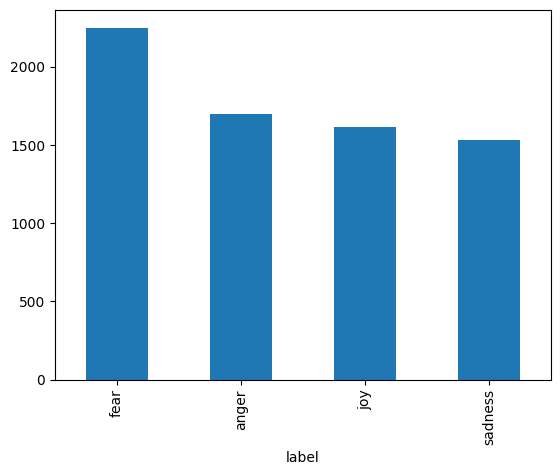

In [49]:
data['label'].value_counts().plot(kind="bar")

<Axes: xlabel='label'>

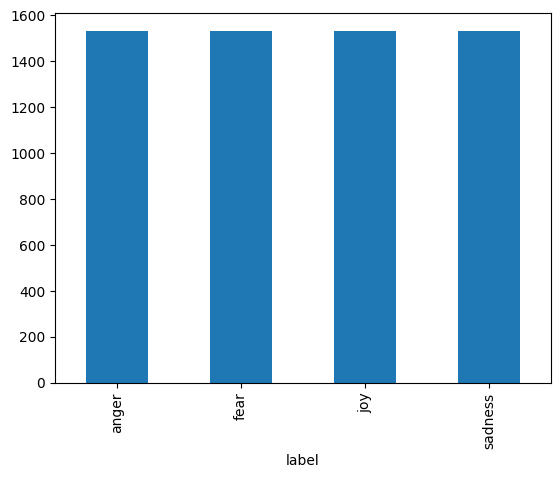

In [50]:
g = data.groupby('label')
data = g.apply(lambda x: x.sample(g.size().min()), include_groups=False).reset_index(level=0)

data['label'].value_counts().plot(kind="bar")

In [51]:
data['label_int'] = LabelEncoder().fit_transform(data['label'])

In [52]:
NUM_LABELS = 4

In [53]:
train_split, test_split = train_test_split(data, train_size = 0.8)
train_split, val_split = train_test_split(train_split, train_size = 0.9)

In [54]:
print(len(train_split))
print(len(test_split))
print(len(val_split))

4414
1227
491


In [55]:
train_df = pd.DataFrame({
    "label":train_split.label_int.values,
    "text":train_split.text_clean.values
})
test_df = pd.DataFrame({
    "label": test_split.label_int.values,
    "text": test_split.text_clean.values
})

In [56]:
train_df = datasets.Dataset.from_dict(train_df)
test_df = datasets.Dataset.from_dict(test_df)

In [57]:
dataset_dict = datasets.DatasetDict({
    "train":train_df,
    "test":test_df
})

In [58]:
dataset_dict

DatasetDict({
    train: Dataset({
        features: ['label', 'text'],
        num_rows: 4414
    })
    test: Dataset({
        features: ['label', 'text'],
        num_rows: 1227
    })
})

### Create embeddings

In [59]:
tokenizer =XLNetTokenizer.from_pretrained("xlnet-base-cased")

In [60]:
def tokenize_function(examples):
    return tokenizer(examples["text"], padding = "max_length", max_length = 128, truncation=True, return_token_type_ids=True)

In [61]:
tokenized_datasets = dataset_dict.map(tokenize_function, batched=True)

Map: 100%|██████████| 1227/1227 [00:00<00:00, 13315.39 examples/s]


In [62]:
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['label', 'text', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 4414
    })
    test: Dataset({
        features: ['label', 'text', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1227
    })
})

In [63]:
print(tokenized_datasets['train']['text'][0])

I #cry out #fear to clear a #path\nBut my Voice seems 2 silent 2 chase a #rat\nAm just indoor #expecting to open door\na #weak wise #fool I am


In [64]:
print(tokenized_datasets['train']['input_ids'][0])

[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 35, 17, 7967, 20828, 78, 17, 7967, 4018, 617, 22, 791, 24, 17, 7967, 9082, 17666, 180, 1294, 94, 10636, 1303, 159, 5548, 159, 9751, 24, 17, 7967, 5235, 17666, 180, 9373, 125, 7789, 17, 7967, 8882, 11615, 56, 22, 433, 887, 17666, 597, 17, 7967, 1603, 1410, 8484, 17, 7967, 6571, 1529, 35, 569, 4, 3]


In [65]:
tokenizer.decode(5)

'<pad>'

In [66]:
print(tokenized_datasets['train']['token_type_ids'][0])

[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2]


In [67]:
print(tokenized_datasets['train']['attention_mask'][0])

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [68]:
small_train_dataset = tokenized_datasets["train"].shuffle(seed=42).select(range(100))
small_eval_dataset = tokenized_datasets["test"].shuffle(seed=42).select(range(100))

### Fine tune model

In [69]:
model = XLNetForSequenceClassification.from_pretrained(
    'xlnet-base-cased', 
    num_labels=NUM_LABELS, 
    id2label={0: 'anger', 1: 'fear', 2: 'joy', 3: 'sadness'}
    )

Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-base-cased and are newly initialized: ['logits_proj.bias', 'logits_proj.weight', 'sequence_summary.summary.bias', 'sequence_summary.summary.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [70]:
metric = evaluate.load("accuracy")

In [71]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return mametric.compute(predictions=predictions, references=labels)

In [72]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="test_trainer",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    num_train_epochs=3
)

In [73]:
metric = evaluate.load("accuracy")

In [74]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

In [75]:
training_args = TrainingArguments(output_dir="test_trainer", eval_strategy="epoch", num_train_epochs=3)

In [76]:
trainer = Trainer(
    model=model, 
    args=training_args,
    train_dataset=small_train_dataset,
    eval_dataset=small_eval_dataset,
    compute_metrics=compute_metrics
    )

In [77]:
trainer.train()

  0%|          | 0/39 [00:00<?, ?it/s]/opt/anaconda3/envs/ai-ml/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
 33%|███▎      | 13/39 [00:05<00:07,  3.34it/s]/opt/anaconda3/envs/ai-ml/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 1.4734015464782715, 'eval_accuracy': 0.28, 'eval_runtime': 1.3676, 'eval_samples_per_second': 73.123, 'eval_steps_per_second': 9.506, 'epoch': 1.0}


 67%|██████▋   | 26/39 [00:11<00:04,  3.22it/s]/opt/anaconda3/envs/ai-ml/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 1.3479329347610474, 'eval_accuracy': 0.37, 'eval_runtime': 1.5251, 'eval_samples_per_second': 65.568, 'eval_steps_per_second': 8.524, 'epoch': 2.0}


100%|██████████| 39/39 [00:16<00:00,  2.32it/s]

{'eval_loss': 1.3568686246871948, 'eval_accuracy': 0.38, 'eval_runtime': 1.504, 'eval_samples_per_second': 66.49, 'eval_steps_per_second': 8.644, 'epoch': 3.0}
{'train_runtime': 16.8081, 'train_samples_per_second': 17.849, 'train_steps_per_second': 2.32, 'train_loss': 1.3133915632199018, 'epoch': 3.0}


TrainOutput(global_step=39, training_loss=1.3133915632199018, metrics={'train_runtime': 16.8081, 'train_samples_per_second': 17.849, 'train_steps_per_second': 2.32, 'total_flos': 21366375321600.0, 'train_loss': 1.3133915632199018, 'epoch': 3.0})

### Evaluate model

In [78]:
trainer.evaluate()

/opt/anaconda3/envs/ai-ml/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 13/13 [00:01<00:00, 10.12it/s]


{'eval_loss': 1.3568686246871948,
 'eval_accuracy': 0.38,
 'eval_runtime': 1.4142,
 'eval_samples_per_second': 70.711,
 'eval_steps_per_second': 9.192,
 'epoch': 3.0}

In [79]:
model.save_pretrained("fine_tuned_model")

In [80]:
fine_tuned_model = XLNetForSequenceClassification.from_pretrained("fine_tuned_model")

In [81]:
clf = pipeline("text-classification", fine_tuned_model, tokenizer=tokenizer)

In [83]:
rand_int = random.randint(0, len(val_split) - 1) 
print(val_split['text_clean'].iloc[rand_int])
answer = clf(val_split['text_clean'].iloc[rand_int], top_k=None)
print(answer)

Wishing a very Happy Birthday to our awesome dancer, Ruthann!!! We hope your day is magical! #bday  #eatcake
[{'label': 'sadness', 'score': 0.3597564101219177}, {'label': 'joy', 'score': 0.3078904151916504}, {'label': 'fear', 'score': 0.2561902701854706}, {'label': 'anger', 'score': 0.07616286724805832}]
